# Klassifikation: Welche Räder müssen als Nächstes in die Werkstatt?

**Verfahren:** Klassifikation (überwachtes Lernen, Zielgröße ist eine Kategorie)  |  **Geschäftsfrage:** Welche 60 Räder soll die Werkstatt im nächsten Quartal vorsorglich prüfen?

[![In Colab öffnen](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/swrobuts/velocity-fallstudie/blob/main/analytics/notebooks/02_Klassifikation_Wartungsrisiko.ipynb)

---

## Wie dieses Notebook aufgebaut ist

Es folgt **CRISP-DM** (*Cross-Industry Standard Process for Data Mining*) — dem
Vorgehensmodell, das seit 1999 der De-facto-Standard für Analyseprojekte ist. Sechs
Phasen, und zwar als **Kreislauf**, nicht als Treppe:

| | Phase | Leitfrage |
|---|---|---|
| 1 | Business Understanding | Was ist die Geschäftsfrage — und woran messen wir Erfolg? |
| 2 | Data Understanding | Welche Daten haben wir, und taugen sie für diese Frage? |
| 3 | Data Preparation | Wie wird aus Rohdaten eine Tabelle, mit der ein Verfahren rechnen kann? |
| 4 | Modeling | Welches Verfahren, welche Einstellungen, wie geprüft? |
| 5 | Evaluation | Ist das Modell gut genug für die Geschäftsfrage aus Phase 1? |
| 6 | Deployment | Wie kommt das Modell in den Betrieb — und was passiert danach? |

**Der Pfeil von Phase 5 zurück auf Phase 1 ist kein Schönheitsfehler des Diagramms.**
Er ist die wichtigste Linie darin. In der Praxis stellt sich in der Evaluation regelmäßig
heraus, dass die Frage aus Phase 1 anders gestellt werden muss oder dass Daten fehlen,
an die in Phase 2 niemand gedacht hat. Ein Analyseprojekt, das die sechs Phasen genau
einmal von oben nach unten durchläuft, ist die Ausnahme — nicht die Regel.

Am Ende dieses Notebooks steht deshalb ausdrücklich die Frage, **was eine zweite Runde
anders machen würde**.

> ### ⚠ Woher die Daten kommen — bitte zuerst lesen
>
> **VeloCity ist ein erfundener Fahrradverleih, und alle Daten dieses Notebooks sind
> erzeugt.** Räder, Fahrten, Schadensmeldungen und Wartungsaufträge hat niemand
> beobachtet; sie stammen aus einem Generator, der die Muster, um die es hier geht,
> **absichtlich verstärkt** eingebaut hat.
>
> Das hat Folgen für jeden Satz, der weiter unten steht:
>
> | | |
> |---|---|
> | **Alle Euro-Beträge** | Szenariorechnungen unter gesetzten Annahmen, keine gemessenen Ersparnisse |
> | **„geht in Betrieb"** | heißt hier: geht in den Lehrbetrieb. Für eine echte Werkstatt müsste alles mit realen Daten neu validiert werden |
> | **Die Trefferquoten** | gelten für diesen Datensatz. Dass die Muster darin sauberer sind als in der Wirklichkeit, ist Absicht |
>
> **Was trotzdem echt ist:** das Vorgehen. Wie man eine Baseline baut, wie man zeitlich
> aufteilt, woran man einen instabilen Modellvorteil erkennt und wann man ein Modell
> nicht ausliefert — das überträgt sich, die Zahlen nicht.

---

**1. Business** · 2. Data · 3. Data · 4. Modeling · 5. Evaluation · 6. Deployment

# Phase 1 von 6 — Business Understanding

> **Leitfrage:** Was ist die Geschäftsfrage — und woran messen wir Erfolg?
>
> **In diesem Notebook heißt das:** Die Werkstatt hat begrenzte Kapazität. Sie soll die Räder prüfen, bei denen sich das lohnt — nicht die, die zufällig oben auf der Liste stehen.

### Die Ausgangslage

VeloCity repariert heute **reaktiv**: Ein Rad fällt aus, jemand meldet es, die Werkstatt
rückt aus. Das ist teuer und ärgerlich — das Rad steht irgendwo im Stadtgebiet, ein
Kunde ist unterwegs liegengeblieben, und der Ruf leidet.

Die Werkstattleitung hat Kapazität für **60 vorsorgliche Prüfungen je Quartal** (rund
fünf pro Werktag, neben dem laufenden Betrieb). Die Frage ist nicht *ob* geprüft wird,
sondern **welche 60 Räder**.

### Warum das eine Klassifikation ist

Gefragt ist keine Zahl, sondern eine **Einteilung**: Wird dieses Rad im nächsten Quartal
eine Schadensmeldung auslösen — ja oder nein? Zwei Klassen, also Klassifikation.

> *„Bei der Klassifikation geht es darum, Elemente anhand ihrer Merkmale automatisiert in
> Klassen einzuteilen. Die Klassen sind vorgegeben, die Klassenzugehörigkeit eines
> Elements ist nicht bekannt.“*
> — Provost/Fawcett, *Data Science für Unternehmen*, S. 45 f.

### Die beiden Fehlerarten sind unterschiedlich teuer

Das ist der Kern dieser Phase, und er entscheidet später über das ganze Modell:

| Fehler | Was passiert | Kosten |
|---|---|---|
| **Falsch negativ** — Modell sagt „unauffällig“, das Rad fällt aber aus | Kunde bleibt liegen, Bergungsfahrt, Ersatz, Beschwerde | **180 €** |
| **Falsch positiv** — Modell sagt „prüfen“, das Rad war in Ordnung | 35 Minuten Werkstattzeit umsonst | **25 €** |

**Ein verpasster Ausfall kostet gut sieben Mal so viel wie eine unnötige Prüfung.**
Ein Modell, das beide Fehler gleich behandelt, optimiert deshalb das Falsche. Wir werden
das in Phase 4 ausdrücklich einstellen müssen.

### Die Erfolgskriterien

| | Kriterium | Schwelle |
|---|---|---|
| **fachlich** | Von den 60 Rädern auf der Quartalsliste müssen mindestens 70 % tatsächlich auffällig werden | sonst verliert die Werkstatt das Vertrauen in die Liste |
| **wirtschaftlich** | Die erwarteten Kosten je Quartal müssen **unter** denen der heutigen Faustregel liegen | die Faustregel lautet: „das älteste Rad zuerst“ |
| **Betrieb** | Die Liste muss ohne Nacharbeit in die Instandhaltungsansicht der Warenwirtschaft übernehmbar sein | |

Das zweite Kriterium ist das wichtigere und wird gerne vergessen: **Ein Modell muss
nicht gut sein, sondern besser als das, was heute schon getan wird.**

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASIS = os.environ.get("VELO_BASIS",
    "https://raw.githubusercontent.com/swrobuts/velocity-fallstudie/main/analytics/")
pd.set_option("display.width", 150)

KOSTEN_VERPASST = 180.0     # falsch negativ: Ausfall auf der Strasse
KOSTEN_UNNOETIG = 25.0      # falsch positiv: Pruefung ohne Befund
KAPAZITAET = 60             # Pruefungen je Quartal
HORIZONT_TAGE = 90          # Vorhersagefenster

print(f"Ein verpasster Ausfall kostet das "
      f"{KOSTEN_VERPASST / KOSTEN_UNNOETIG:.1f}-fache einer unnötigen Prüfung.")
print(f"Kapazität: {KAPAZITAET} Räder je Quartal, Vorhersagefenster {HORIZONT_TAGE} Tage.")

Ein verpasster Ausfall kostet das 7.2-fache einer unnötigen Prüfung.
Kapazität: 60 Räder je Quartal, Vorhersagefenster 90 Tage.


---

1. Business · **2. Data** · 3. Data · 4. Modeling · 5. Evaluation · 6. Deployment

# Phase 2 von 6 — Data Understanding

> **Leitfrage:** Welche Daten haben wir, und taugen sie für diese Frage?
>
> **In diesem Notebook heißt das:** Wie oft fallen Räder überhaupt aus, und hängt das erkennbar mit ihrer Nutzung zusammen? Ohne einen solchen Zusammenhang wäre das Projekt hier zu Ende.

In [2]:
raeder = pd.read_csv(BASIS + "fahrrad.csv", parse_dates=["angeschafft_am", "ausgemustert_am"])
schaeden = pd.read_csv(BASIS + "schadensmeldung.csv", parse_dates=["gemeldet_am"])
auftraege = pd.read_csv(BASIS + "wartungsauftrag.csv", parse_dates=["eroeffnet_am", "erledigt_am"])
fahrten = pd.read_csv(BASIS + "ausleihe.csv", parse_dates=["startzeit", "endzeit"])

print(f"Räder:              {len(raeder):>6d}   davon ausgemustert: {(raeder.status=='ausgemustert').sum()}")
print(f"Schadensmeldungen:  {len(schaeden):>6d}")
print(f"Wartungsaufträge:   {len(auftraege):>6d}")
print(f"Fahrten:            {len(fahrten):>6d}")
print(f"\nZeitraum der Meldungen: {schaeden.gemeldet_am.min().date()} bis {schaeden.gemeldet_am.max().date()}")
print("\nSchwere der Meldungen:")
print(schaeden.schwere.value_counts().to_string())
print("\nHäufigste Kategorien:")
print(schaeden.kategorie.value_counts().head(5).to_string())

Räder:                 240   davon ausgemustert: 12
Schadensmeldungen:     640
Wartungsaufträge:      640
Fahrten:             60425

Zeitraum der Meldungen: 2023-09-02 bis 2026-08-23

Schwere der Meldungen:
schwere
mittel            228
fahruntauglich    226
leicht            186

Häufigste Kategorien:
kategorie
Reifen/Platten        104
Sattel/Sitzhaltung     94
Rahmen/Lenker          91
Licht                  91
Schaltung              89


### 2.1 Wie verteilen sich die Meldungen auf die Flotte?

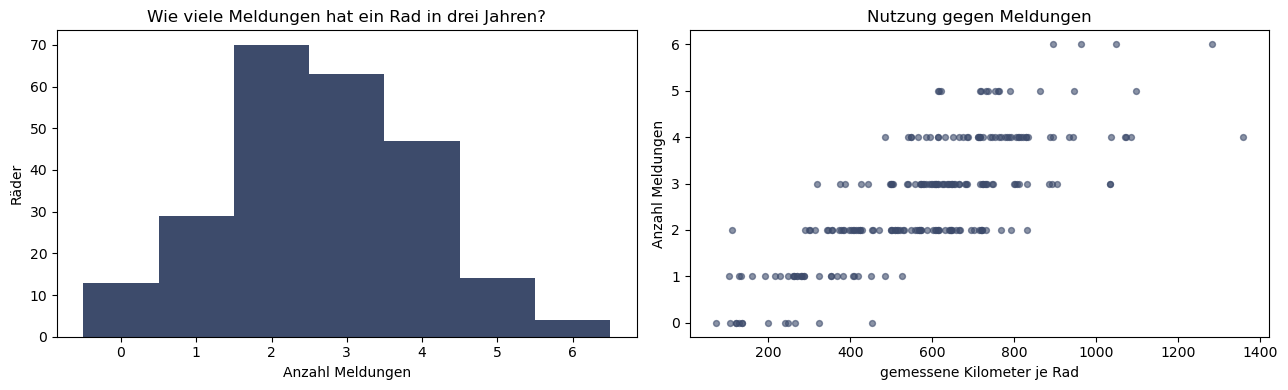

Korrelation Kilometer <-> Meldungen: r = 0.764
Meldungen je Rad: Mittel 2.7, Median 3, Maximum 6


In [3]:
je_rad = schaeden.groupby("fahrrad_id").size().reindex(raeder.fahrrad_id, fill_value=0)

fig, achsen = plt.subplots(1, 2, figsize=(13, 4))
achsen[0].hist(je_rad, bins=range(0, int(je_rad.max()) + 2), color="#3d4b6b", align="left")
achsen[0].set_title("Wie viele Meldungen hat ein Rad in drei Jahren?")
achsen[0].set_xlabel("Anzahl Meldungen"); achsen[0].set_ylabel("Räder")

nutzung = fahrten[fahrten.status == "abgeschlossen"].groupby("fahrrad_id").agg(
    fahrten_gesamt=("ausleihe_id", "size"),
    km_gesamt=("distanz_km", "sum"),
)
verbund = raeder.set_index("fahrrad_id").join(nutzung).join(je_rad.rename("meldungen"))
verbund["fahrten_gesamt"] = verbund.fahrten_gesamt.fillna(0)

achsen[1].scatter(verbund.km_gesamt, verbund.meldungen, s=18, alpha=.6, color="#3d4b6b")
achsen[1].set_xlabel("gemessene Kilometer je Rad"); achsen[1].set_ylabel("Anzahl Meldungen")
achsen[1].set_title("Nutzung gegen Meldungen")
plt.tight_layout(); plt.show()

r = verbund[["km_gesamt", "meldungen"]].corr().iloc[0, 1]
print(f"Korrelation Kilometer <-> Meldungen: r = {r:.3f}")
print(f"Meldungen je Rad: Mittel {je_rad.mean():.1f}, Median {je_rad.median():.0f}, "
      f"Maximum {je_rad.max()}")

**Der Zusammenhang ist da, aber er ist nicht perfekt** — und genau so soll es sein. Bei
r ≈ 0,7 gibt es viel gemeinsame Bewegung und trotzdem Räder, die viel gefahren wurden
und selten melden, und umgekehrt. Wäre r = 0,99, bräuchte man kein Modell, sondern eine
Sortierung nach Kilometern. Wäre r = 0,1, wäre nichts zu lernen.

### 2.2 Die entscheidende Frage der Datenaufbereitung: Wann fragen wir?

In [4]:
# Wieviele Raeder melden sich in einem 90-Tage-Fenster?
ende = fahrten.startzeit.max().normalize()
stichtag = ende - pd.Timedelta(days=HORIZONT_TAGE)
im_bestand = raeder[(raeder.angeschafft_am <= stichtag)
                    & (raeder.ausgemustert_am.isna() | (raeder.ausgemustert_am > stichtag))]
melden = set(schaeden[schaeden.gemeldet_am > stichtag].fahrrad_id)
positiv = im_bestand.fahrrad_id.isin(melden)

print(f"Stichtag: {stichtag.date()}, Fenster bis {ende.date()}")
print(f"Räder im Bestand:             {len(im_bestand)}")
print(f"davon mit Meldung im Fenster: {positiv.sum()}  ({positiv.mean():.1%})")
print(f"\nWerkstattkapazität {KAPAZITAET} von {len(im_bestand)} Rädern "
      f"= {KAPAZITAET/len(im_bestand):.0%} der Flotte")

Stichtag: 2026-05-26, Fenster bis 2026-08-24
Räder im Bestand:             228
davon mit Meldung im Fenster: 103  (45.2%)

Werkstattkapazität 60 von 228 Rädern = 26% der Flotte


Rund **44 % der Räder** melden sich in einem Quartal — die Klassen sind also gut besetzt.
Aber die Werkstatt kann nur **26 % der Flotte** prüfen. Das Modell muss also nicht nur
richtig liegen, sondern **priorisieren**: Es muss sagen, welche Räder am dringendsten
sind, nicht nur welche überhaupt auffällig werden. Darauf kommen wir in Phase 5 zurück.

---

1. Business · 2. Data · **3. Data** · 4. Modeling · 5. Evaluation · 6. Deployment

# Phase 3 von 6 — Data Preparation

> **Leitfrage:** Wie wird aus Rohdaten eine Tabelle, mit der ein Verfahren rechnen kann?
>
> **In diesem Notebook heißt das:** Wir bauen eine Tabelle, in der jede Zeile eine **Frage zu einem Zeitpunkt** ist: „Rad 47, Stand 1. April — meldet es sich bis zum 30. Juni?\“

### 3.1 Der häufigste Fehler bei Wartungsvorhersagen

Man nimmt jedes Rad, zählt seine Kilometer **über den gesamten Zeitraum** und fragt: hat
es je eine Meldung gehabt? Das ergibt eine schöne Tabelle — und ein wertloses Modell.

**Warum:** Die Kilometer eines Rades, das im Januar ausfiel, enthalten auch die
Kilometer *nach* dem Januar. Das Modell lernt aus der Zukunft. Und die Frage „hat es je
gemeldet?“ hilft der Werkstatt nicht, denn sie plant *das nächste Quartal*.

**Richtig ist ein Schnitt in der Zeit:**

```
   Merkmale               Stichtag              Label
   ├──── 180 Tage ────────┤                      │
   Fahrten, km, frühere   │  ←→  90 Tage  →  Meldung ja/nein
   Meldungen ...          │
```

Alles links vom Stichtag darf ins Modell. Alles rechts davon ist das, was vorhergesagt
werden soll — und muss beim Rechnen unsichtbar bleiben.

### 3.2 Die Frage mehrfach stellen

Ein einziger Stichtag ergäbe 228 Zeilen — zu wenig. Wir stellen dieselbe Frage deshalb
zu **mehreren Zeitpunkten**, im Abstand eines Quartals. Jedes Rad taucht dann mehrfach
auf, aber mit *unterschiedlichem* Wissensstand und *unterschiedlichem* Ausgang. Das ist
kein Trick, sondern genau die Art, wie solche Modelle in der Praxis gebaut werden.

In [5]:
abgeschlossen = fahrten[fahrten.status == "abgeschlossen"].copy()
abgeschlossen["dauer_min"] = (abgeschlossen.endzeit - abgeschlossen.startzeit).dt.total_seconds() / 60
vorher = len(abgeschlossen)

# AUSREISSER ZUERST - sonst wandern sie in jedes Verschleissmerkmal.
# Eine Fahrt ueber acht Stunden ist keine Fahrt, sondern eine vergessene
# Rueckgabe. Bei 11 bis 18 km/h ergaebe die laengste davon knapp 300
# geschaetzte Kilometer an EINEM Tag - und traegt ein Rad weit nach oben.
LANGFAHRT_STUNDEN = 8
lang = abgeschlossen.dauer_min > LANGFAHRT_STUNDEN * 60
print(f"Fahrten über {LANGFAHRT_STUNDEN} Stunden: {lang.sum()} "
      f"(längste {abgeschlossen.dauer_min.max():.0f} Minuten) - ausgeschlossen")
abgeschlossen = abgeschlossen[~lang].copy()
print(f"Abgeschlossene Fahrten: {vorher} -> {len(abgeschlossen)}")

# DIE SENSORLUECKE SCHLIESSEN - aber erst NACH dem Messwert.
# Wo eine Distanz gemessen wurde, wird sie verwendet. Nur die Luecke wird
# geschaetzt. Alles zu schaetzen hiesse, sechs von zehn vorhandenen
# Messungen wegzuwerfen, weil vier fehlen.
TYPISCHE_GESCHWINDIGKEIT = {"CITY": 13.0, "EBIKE": 18.0, "CARGO": 11.0}   # km/h
abgeschlossen = abgeschlossen.merge(raeder[["fahrrad_id", "typ_code"]], on="fahrrad_id", how="left")
schaetzung = (abgeschlossen.dauer_min / 60.0
              * abgeschlossen.typ_code.map(TYPISCHE_GESCHWINDIGKEIT))
hat_messwert = abgeschlossen.distanz_km.notna()
abgeschlossen["km_fahrt"] = abgeschlossen.distanz_km.where(hat_messwert, schaetzung)
abgeschlossen["km_geschaetzt"] = ~hat_messwert

abweichung = (schaetzung[hat_messwert] - abgeschlossen.distanz_km[hat_messwert]).abs().mean()
print(f"\nGemessen:   {hat_messwert.sum():>6d} Fahrten ({hat_messwert.mean():.1%})")
print(f"Geschätzt:  {(~hat_messwert).sum():>6d} Fahrten ({(~hat_messwert).mean():.1%})")
print(f"Wo beides vorliegt, weicht die Schätzung im Mittel um {abweichung:.2f} km ab")
print(f"(mittlere gemessene Strecke: {abgeschlossen.distanz_km[hat_messwert].mean():.2f} km)")

# WIE LANGE STEHT EIN SCHADEN OFFEN? Diese Zahl entscheidet, ob der
# Unterschied zwischen "seit der Meldung" und "seit der Reparatur"
# fachlich zaehlt oder eine Spitzfindigkeit ist.
werkstatt = schaeden.merge(auftraege[["schadensmeldung_id", "erledigt_am"]],
                           on="schadensmeldung_id", how="left")
liegezeit = (werkstatt.erledigt_am - werkstatt.gemeldet_am).dt.total_seconds() / 86400
dazwischen = werkstatt.dropna(subset=["erledigt_am"]).merge(
    abgeschlossen[["fahrrad_id", "startzeit"]], on="fahrrad_id", how="left")
ist_dazwischen = ((dazwischen.startzeit > dazwischen.gemeldet_am)
                  & (dazwischen.startzeit <= dazwischen.erledigt_am))
print(f"Zwischen Meldung und erledigter Reparatur vergehen im Mittel "
      f"{liegezeit.mean():.1f} Tage (höchstens {liegezeit.max():.1f}).")
print(f"In dieser Zeit wird weitergefahren: "
      f"{dazwischen[ist_dazwischen].schadensmeldung_id.nunique()} von "
      f"{werkstatt.erledigt_am.notna().sum()} Meldungen betroffen, "
      f"{int(ist_dazwischen.sum())} Fahrten.")
print("Diese Kilometer gehen auf das ALTE Bauteil - also wird bei der")
print("Reparatur zurückgesetzt, nicht bei der Meldung.")

RUECKBLICK_TAGE = 180

def zeile_bauen(stichtag):
    """Eine Momentaufnahme der Flotte: Merkmale aus der Vergangenheit, Label aus der Zukunft."""
    bestand = raeder[(raeder.angeschafft_am <= stichtag - pd.Timedelta(days=30))
                     & (raeder.ausgemustert_am.isna() | (raeder.ausgemustert_am > stichtag))].copy()

    # --- Merkmale: NUR aus der Zeit VOR dem Stichtag
    fenster = abgeschlossen[(abgeschlossen.startzeit > stichtag - pd.Timedelta(days=RUECKBLICK_TAGE))
                            & (abgeschlossen.startzeit <= stichtag)]
    nutzung_fenster = fenster.groupby("fahrrad_id").agg(
        fahrten_180=("ausleihe_id", "size"),
        km_180=("km_fahrt", "sum"),
        dauer_mittel=("dauer_min", "mean"),
    )
    bis_jetzt = abgeschlossen[abgeschlossen.startzeit <= stichtag]
    gesamt = bis_jetzt.groupby("fahrrad_id").agg(
        fahrten_gesamt=("ausleihe_id", "size"),
        km_gesamt=("km_fahrt", "sum"),
    )
    frueher = schaeden[schaeden.gemeldet_am <= stichtag]
    meldungen_bisher = frueher.groupby("fahrrad_id").size().rename("meldungen_bisher")

    # KILOMETER SEIT DER LETZTEN ERLEDIGTEN REPARATUR.
    #
    # Nicht seit der MELDUNG: Zwischen beidem wird weitergefahren - die
    # Zahlen dazu stehen oben, gerechnet statt behauptet. Diese Kilometer
    # gehen auf das ALTE Bauteil. Wer bei der Meldung zuruecksetzt,
    # schreibt sie dem neuen gut und macht das wichtigste Merkmal des
    # Notebooks systematisch zu klein - ausgerechnet bei den Raedern, die
    # gerade auffaellig waren.
    erledigt = schaeden.merge(
        auftraege[["schadensmeldung_id", "erledigt_am"]], on="schadensmeldung_id", how="left")
    fertig = erledigt[erledigt.erledigt_am.notna() & (erledigt.erledigt_am <= stichtag)]
    letzte_reparatur = fertig.groupby("fahrrad_id").erledigt_am.max().rename("letzte_reparatur")

    seit = bis_jetzt.merge(letzte_reparatur, left_on="fahrrad_id", right_index=True, how="left")
    nach_reparatur = seit.letzte_reparatur.isna() | (seit.startzeit > seit.letzte_reparatur)
    km_seit = seit[nach_reparatur].groupby("fahrrad_id").km_fahrt.sum().rename("km_seit_reparatur")

    # OFFENE SCHAEDEN GEHOEREN NICHT IN EINE RISIKOLISTE.
    # Ein Rad mit gemeldetem, noch nicht erledigtem Schaden muss ohnehin in
    # die Werkstatt. Es auf die Vorsorgeliste zu setzen verbraucht einen der
    # 60 Plaetze fuer eine Entscheidung, die schon gefallen ist.
    offen = set(erledigt[(erledigt.gemeldet_am <= stichtag)
                         & (erledigt.erledigt_am.isna()
                            | (erledigt.erledigt_am > stichtag))].fahrrad_id)
    bestand = bestand[~bestand.fahrrad_id.isin(offen)]

    z = bestand.set_index("fahrrad_id").join(
        [nutzung_fenster, gesamt, meldungen_bisher, letzte_reparatur, km_seit])
    for spalte in ["fahrten_180", "km_180", "fahrten_gesamt", "km_gesamt",
                   "meldungen_bisher", "km_seit_reparatur"]:
        z[spalte] = z[spalte].fillna(0)
    z["dauer_mittel"] = z.dauer_mittel.fillna(z.dauer_mittel.median())
    z["tage_im_bestand"] = (stichtag - z.angeschafft_am).dt.days
    z["tage_seit_reparatur"] = (stichtag - z.letzte_reparatur).dt.days.fillna(9999)
    z["km_je_tag"] = z.km_gesamt / z.tage_im_bestand.clip(lower=1)

    # --- Label: NUR aus der Zeit NACH dem Stichtag
    kuenftig = set(schaeden[(schaeden.gemeldet_am > stichtag)
                            & (schaeden.gemeldet_am <= stichtag + pd.Timedelta(days=HORIZONT_TAGE))].fahrrad_id)
    z["meldet_sich"] = z.index.isin(kuenftig).astype(int)
    z["stichtag"] = stichtag
    return z.reset_index()

stichtage = pd.date_range(end=ende - pd.Timedelta(days=HORIZONT_TAGE), periods=8, freq="90D")

panel = pd.concat([zeile_bauen(s) for s in stichtage], ignore_index=True)

print("Stichtage:", ", ".join(str(s.date()) for s in stichtage))
print(f"\nZeilen im Panel: {len(panel)}   ({len(stichtage)} Stichtage × rund "
      f"{len(panel)//len(stichtage)} Räder)")
print(f"Anteil positiver Fälle: {panel.meldet_sich.mean():.1%}")
print("\nAnteil je Stichtag:")
print(panel.groupby(panel.stichtag.dt.date).meldet_sich.agg(["size", "mean"]).round(3).to_string())

Fahrten über 8 Stunden: 45 (längste 1777 Minuten) - ausgeschlossen
Abgeschlossene Fahrten: 58737 -> 58692

Gemessen:    35163 Fahrten (59.9%)
Geschätzt:   23529 Fahrten (40.1%)
Wo beides vorliegt, weicht die Schätzung im Mittel um 0.37 km ab
(mittlere gemessene Strecke: 3.74 km)
Zwischen Meldung und erledigter Reparatur vergehen im Mittel 2.8 Tage (höchstens 6.7).
In dieser Zeit wird weitergefahren: 505 von 639 Meldungen betroffen, 1026 Fahrten.
Diese Kilometer gehen auf das ALTE Bauteil - also wird bei der
Reparatur zurückgesetzt, nicht bei der Meldung.


Stichtage: 2024-09-03, 2024-12-02, 2025-03-02, 2025-05-31, 2025-08-29, 2025-11-27, 2026-02-25, 2026-05-26

Zeilen im Panel: 1670   (8 Stichtage × rund 208 Räder)
Anteil positiver Fälle: 26.1%

Anteil je Stichtag:
            size   mean
stichtag               
2024-09-03   172  0.273
2024-12-02   193  0.109
2025-03-02   207  0.227
2025-05-31   209  0.469
2025-08-29   215  0.265
2025-11-27   223  0.076
2026-02-25   227  0.207
2026-05-26   224  0.455


> **Sehen Sie sich die Spalte `mean` genau an.** Der Anteil auffälliger Räder schwankt
> zwischen rund **8 % im November und 46 % im Mai** — um mehr als das Fünffache. Das ist kein
> Fehler in den Daten, sondern die Jahreszeit: Im Winter wird kaum gefahren, also
> verschleißt kaum etwas, also meldet sich kaum ein Rad.
>
> Für uns hat das zwei Folgen, und beide sind unangenehm:
>
> 1. **Die Testmenge ist ein Mai-Stichtag** — ein Zeitpunkt mit hohem Anteil. Ein Modell,
>    das auf gemischten Jahreszeiten trainiert wurde, ist dort systematisch zu
>    zurückhaltend.
> 2. **Die Kapazität von 60 Rädern passt nicht zu jeder Jahreszeit.** Im November wären
>    60 Prüfungen Verschwendung, im Mai zu wenig.
>
> Wir lassen das hier so stehen und kommen am Ende darauf zurück — es ist einer der
> Punkte, an denen eine zweite Runde ansetzen müsste.

### 3.3 Aufteilen — zeitlich, nicht zufällig

In [6]:
merkmale = ["fahrten_180", "km_180", "dauer_mittel", "fahrten_gesamt", "km_gesamt",
            "meldungen_bisher", "tage_im_bestand", "tage_seit_reparatur", "km_je_tag",
            "km_seit_reparatur"]
typ_dummies = pd.get_dummies(panel["typ_code"], prefix="typ").astype(int)
X_alle = pd.concat([panel[merkmale], typ_dummies], axis=1)
y_alle = panel["meldet_sich"]

# Der LETZTE Stichtag ist die Testmenge - so, wie es im Betrieb waere:
# trainieren auf allem Vergangenen, anwenden auf den heutigen Stand.
letzter = stichtage[-1]
ist_test = panel.stichtag == letzter

X_train, y_train = X_alle[~ist_test], y_alle[~ist_test]
X_test, y_test = X_alle[ist_test], y_alle[ist_test]

print(f"Training: {len(X_train)} Zeilen aus {ist_test.sum() and len(stichtage)-1} Stichtagen "
      f"(bis {stichtage[-2].date()})")
print(f"Test:     {len(X_test)} Zeilen vom Stichtag {letzter.date()}")
print(f"Anteil positiv  Training {y_train.mean():.1%} | Test {y_test.mean():.1%}")

Training: 1446 Zeilen aus 7 Stichtagen (bis 2026-02-25)
Test:     224 Zeilen vom Stichtag 2026-05-26
Anteil positiv  Training 23.1% | Test 45.5%


> **Warum nicht `train_test_split` wie in Notebook 1?** Weil dasselbe Rad in mehreren
> Zeilen vorkommt. Ein zufälliger Schnitt würde Rad 47 vom Januar ins Training und Rad 47
> vom April in den Test legen — das Modell hätte das Rad dann schon gesehen und sähe
> besser aus, als es ist. Der Schnitt entlang der Zeit vermeidet das und bildet
> zusätzlich die Betriebslage ab.

---

1. Business · 2. Data · 3. Data · **4. Modeling** · 5. Evaluation · 6. Deployment

# Phase 4 von 6 — Modeling

> **Leitfrage:** Welches Verfahren, welche Einstellungen, wie geprüft?
>
> **In diesem Notebook heißt das:** Erst die Faustregel, die es zu schlagen gilt. Dann Modelle — und zwar mit eingebauter Kostenasymmetrie.

### 4.1 Die Faustregeln als Maßstab

Bevor ein Modell antritt, muss klar sein, wogegen. Drei Regeln, die eine Werkstatt ohne
jedes Modell anwenden könnte:

1. **„Das älteste Rad zuerst“** — die heutige Praxis
2. **„Das meistgefahrene Rad zuerst“** — die naheliegende Verbesserung
3. **„Das Rad mit den meisten Kilometern seit der letzten Reparatur zuerst“** — die
   Regel, die ein Werkstattmeister vorschlagen würde

Die dritte ist nicht raffinierter als die zweite, sondern **sachkundiger**. Sie steckt
kein bisschen mehr Mathematik, sondern das Wissen, dass ein Bremsbelag nicht zählt,
wieviel das Rad in seinem Leben gefahren ist, sondern nur, wieviel seit seinem Einbau.

Jede der drei liefert eine Rangfolge, und aus einer Rangfolge wird eine Liste der Top 60.

In [7]:
def liste_bewerten(name, rangfolge, y_wahr, kapazitaet=KAPAZITAET):
    """Nimmt die obersten k Raeder einer Rangfolge und rechnet nach, was das kostet."""
    reihenfolge = np.argsort(-np.asarray(rangfolge))
    gewaehlt = np.zeros(len(y_wahr), dtype=bool)
    gewaehlt[reihenfolge[:kapazitaet]] = True
    y = np.asarray(y_wahr)

    richtig_geprueft = int((gewaehlt & (y == 1)).sum())      # Ausfall verhindert
    unnoetig = int((gewaehlt & (y == 0)).sum())              # umsonst geprueft
    verpasst = int((~gewaehlt & (y == 1)).sum())             # Ausfall auf der Strasse
    kosten = verpasst * KOSTEN_VERPASST + unnoetig * KOSTEN_UNNOETIG
    return {"Vorgehen": name, "Treffer": richtig_geprueft,
            "Trefferquote": round(richtig_geprueft / kapazitaet, 3),
            "unnötig geprüft": unnoetig, "Ausfälle verpasst": verpasst,
            "Kosten (EUR)": round(kosten, 0)}

test_zeilen = panel[ist_test].reset_index(drop=True)
vergleich = []

# Nichts tun - alle Ausfaelle passieren
alle_verpasst = int(y_test.sum())
vergleich.append({"Vorgehen": "gar nicht vorsorglich prüfen", "Treffer": 0, "Trefferquote": 0.0,
                  "unnötig geprüft": 0, "Ausfälle verpasst": alle_verpasst,
                  "Kosten (EUR)": round(alle_verpasst * KOSTEN_VERPASST, 0)})
vergleich.append(liste_bewerten("Faustregel: ältestes Rad zuerst",
                                test_zeilen.tage_im_bestand.values, y_test))
vergleich.append(liste_bewerten("Faustregel: meiste Kilometer gesamt",
                                test_zeilen.km_gesamt.values, y_test))
vergleich.append(liste_bewerten("Faustregel: km seit letzter Reparatur",
                                test_zeilen.km_seit_reparatur.values, y_test))
# Trefferquote als Prozent: Als Dezimalzahl muss sie jeder Leser - und
# jede Folie, die auf diese Tabelle zeigt - selbst umrechnen.
def als_prozent(df):
    d = df.copy()
    d["Trefferquote"] = d["Trefferquote"].map(lambda x: f"{x:.1%}")
    return d

print(als_prozent(pd.DataFrame(vergleich)).to_string(index=False))

                             Vorgehen  Treffer Trefferquote  unnötig geprüft  Ausfälle verpasst  Kosten (EUR)
         gar nicht vorsorglich prüfen        0         0.0%                0                102       18360.0
      Faustregel: ältestes Rad zuerst       27        45.0%               33                 75       14325.0
  Faustregel: meiste Kilometer gesamt       31        51.7%               29                 71       13505.0
Faustregel: km seit letzter Reparatur       43        71.7%               17                 59       11045.0


**Diese Tabelle ist der Kern des ganzen Notebooks — lesen Sie sie langsam.**

Die ersten beiden Regeln liegen dicht beieinander; welche vorn liegt, ist fast Zufall.
Die dritte springt um achtzehn Punkte nach oben — und zwischen ihr und den anderen liegt
**kein einziger Rechenschritt Unterschied**, nur ein anderes Verständnis davon, wie
Verschleiß entsteht.

Merken Sie sich diese Zahlen. Wir kommen in Phase 5 darauf zurück, wenn das Modell
gerechnet hat — und das Ergebnis wird ungemütlich.

### 4.2 Entscheidungsbaum — mit Gewichtung der Klassen

Klassengewichte: {0: 1.0, 1: 7.2}


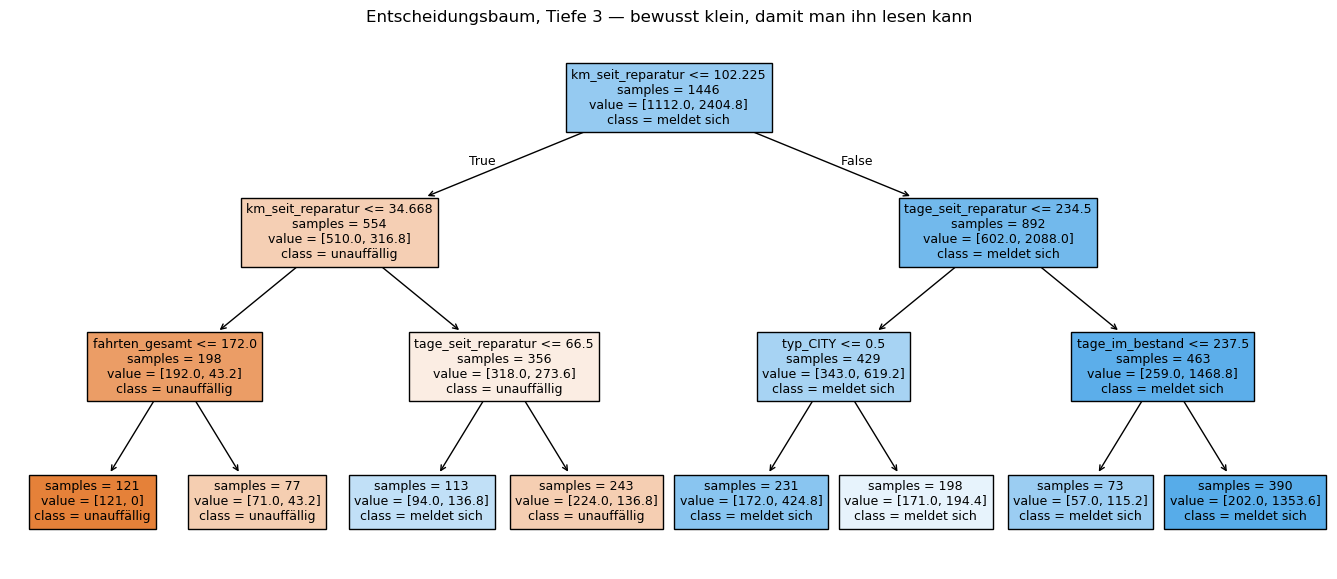

In [8]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# class_weight uebersetzt die Kostenasymmetrie aus Phase 1 in das Modell:
# ein verpasster Ausfall wiegt gut sieben unnoetige Pruefungen auf.
gewichte = {0: 1.0, 1: KOSTEN_VERPASST / KOSTEN_UNNOETIG}
print("Klassengewichte:", {k: round(v, 1) for k, v in gewichte.items()})

baum = DecisionTreeClassifier(max_depth=3, min_samples_leaf=40,
                              class_weight=gewichte, random_state=42)
baum.fit(X_train, y_train)

plt.figure(figsize=(17, 7))
plot_tree(baum, feature_names=list(X_alle.columns),
          class_names=["unauffällig", "meldet sich"], filled=True, fontsize=9, impurity=False)
plt.title("Entscheidungsbaum, Tiefe 3 — bewusst klein, damit man ihn lesen kann")
plt.show()

**Einen Baum kann man vorlesen.** Genau das macht ihn für den Einstieg so wertvoll und
in der Praxis so überzeugend: Die Werkstattleitung sieht, *warum* ein Rad auf der Liste
steht, und kann widersprechen. Bei einem Random Forest oder einem neuronalen Netz geht
das nicht mehr.

Die oberste Verzweigung ist die wichtigste Frage, die das Modell stellt. Sehen Sie nach,
welches Merkmal dort steht.

### 4.3 Random Forest

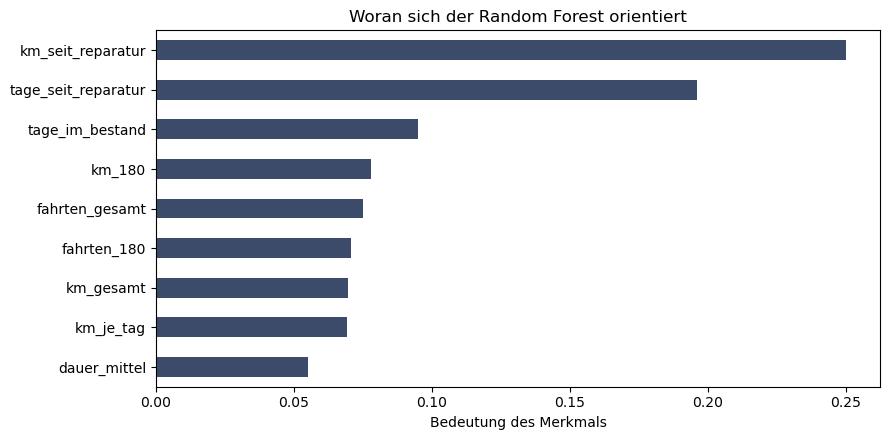

km_seit_reparatur      0.250
tage_seit_reparatur    0.196
tage_im_bestand        0.095
km_180                 0.078
fahrten_gesamt         0.075
fahrten_180            0.071
km_gesamt              0.070
km_je_tag              0.069
dauer_mittel           0.055
meldungen_bisher       0.018
typ_CITY               0.013
typ_EBIKE              0.006
typ_CARGO              0.004


In [9]:
wald = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=10,
                              class_weight=gewichte, random_state=42, n_jobs=-1)
wald.fit(X_train, y_train)

wichtigkeit = pd.Series(wald.feature_importances_, index=X_alle.columns).sort_values(ascending=False)
plt.figure(figsize=(9, 4.5))
wichtigkeit.head(9).iloc[::-1].plot(kind="barh", color="#3d4b6b")
plt.title("Woran sich der Random Forest orientiert"); plt.xlabel("Bedeutung des Merkmals")
plt.tight_layout(); plt.show()
print(wichtigkeit.round(3).to_string())

> **Vorsicht bei der Deutung.** „Bedeutung des Merkmals“ heißt hier: wie oft und wie
> wirksam der Wald an diesem Merkmal aufgeteilt hat. Das ist **keine Ursache-Wirkung**.
> Dass `tage_seit_reparatur` weit oben steht, heißt nicht, dass langes Schweigen einen
> Defekt verursacht — es heißt, dass dieses Merkmal die Räder gut trennt.

---

1. Business · 2. Data · 3. Data · 4. Modeling · **5. Evaluation** · 6. Deployment

# Phase 5 von 6 — Evaluation

> **Leitfrage:** Ist das Modell gut genug für die Geschäftsfrage aus Phase 1?
>
> **In diesem Notebook heißt das:** Confusion-Matrix, Kosten und die Frage, ob wir die Faustregel überhaupt schlagen.

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

for name, modell in [("Entscheidungsbaum", baum), ("Random Forest", wald)]:
    wahrscheinlichkeit = modell.predict_proba(X_test)[:, 1]
    vergleich.append(liste_bewerten(f"Modell: {name}", wahrscheinlichkeit, y_test))

tabelle = pd.DataFrame(vergleich)
print(als_prozent(tabelle).to_string(index=False))

bestes = tabelle.loc[tabelle["Kosten (EUR)"].idxmin(), "Vorgehen"]
ersparnis = tabelle["Kosten (EUR)"].iloc[0] - tabelle["Kosten (EUR)"].min()
print(f"\nGünstigstes Vorgehen: {bestes}")
print(f"Ersparnis gegenüber 'gar nicht prüfen': {ersparnis:,.0f} EUR je Quartal".replace(",", "."))

                             Vorgehen  Treffer Trefferquote  unnötig geprüft  Ausfälle verpasst  Kosten (EUR)
         gar nicht vorsorglich prüfen        0         0.0%                0                102       18360.0
      Faustregel: ältestes Rad zuerst       27        45.0%               33                 75       14325.0
  Faustregel: meiste Kilometer gesamt       31        51.7%               29                 71       13505.0
Faustregel: km seit letzter Reparatur       43        71.7%               17                 59       11045.0
            Modell: Entscheidungsbaum       37        61.7%               23                 65       12275.0
                Modell: Random Forest       43        71.7%               17                 59       11045.0

Günstigstes Vorgehen: Faustregel: km seit letzter Reparatur
Ersparnis gegenüber 'gar nicht prüfen': 7.315 EUR je Quartal


### 5.1 Die Confusion-Matrix — welche Art Fehler macht das Modell?

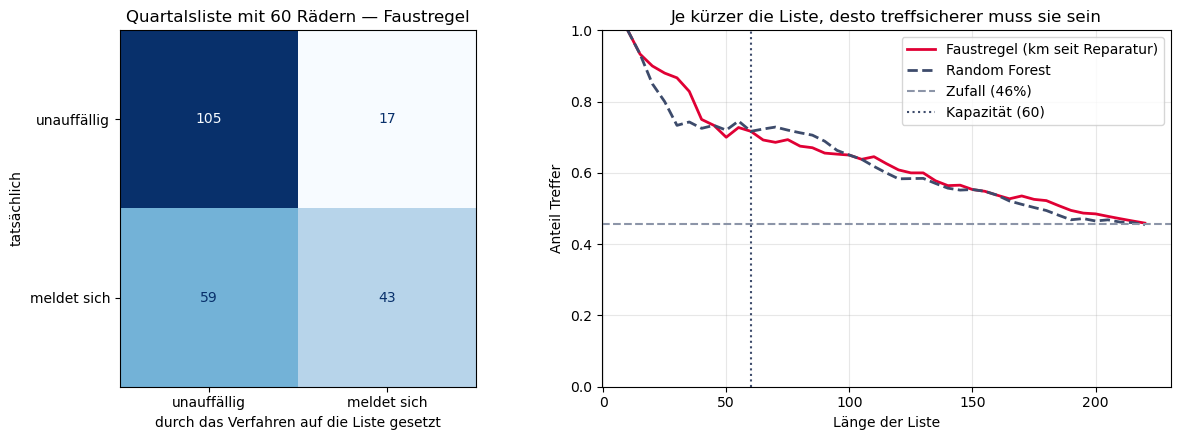

Klassifikationsbericht der FAUSTREGEL (das Modell folgt in 5.5):
              precision    recall  f1-score   support

 unauffällig      0.640     0.861     0.734       122
 meldet sich      0.717     0.422     0.531       102

    accuracy                          0.661       224
   macro avg      0.678     0.641     0.633       224
weighted avg      0.675     0.661     0.642       224



In [11]:
p_wald = wald.predict_proba(X_test)[:, 1]
p_regel = test_zeilen.km_seit_reparatur.values     # die Faustregel als Rangfolge

# Hier steht noch KEINE Entscheidung - die faellt in 5.6. Diese Grafik
# zeigt deshalb BEIDE Kandidaten nebeneinander, damit niemand eine
# Confusion-Matrix fuer das eine Verfahren mit dem Urteil ueber das
# andere verwechselt. Genau das war in einer frueheren Fassung passiert.
reihenfolge = np.argsort(-p_regel)
auf_liste = np.zeros(len(y_test), dtype=bool)
auf_liste[reihenfolge[:KAPAZITAET]] = True

cm = confusion_matrix(y_test, auf_liste.astype(int))
fig, achsen = plt.subplots(1, 2, figsize=(12.5, 4.5))
ConfusionMatrixDisplay(cm, display_labels=["unauffällig", "meldet sich"]).plot(
    cmap="Blues", ax=achsen[0], colorbar=False)
achsen[0].set_title(f"Quartalsliste mit {KAPAZITAET} Rädern — Faustregel")
achsen[0].set_xlabel("durch das Verfahren auf die Liste gesetzt")
achsen[0].set_ylabel("tatsächlich")

# Wie gut ist die Rangfolge? Trefferquote in Abhaengigkeit der Listenlaenge.
laengen = range(10, len(y_test) + 1, 5)
quoten = []
for k in laengen:
    gew = np.zeros(len(y_test), dtype=bool); gew[reihenfolge[:k]] = True
    quoten.append((np.asarray(y_test)[gew] == 1).mean())
quoten_wald = []
for k_ in laengen:
    g = np.zeros(len(y_test), dtype=bool); g[np.argsort(-p_wald)[:k_]] = True
    quoten_wald.append((np.asarray(y_test)[g] == 1).mean())
achsen[1].plot(list(laengen), quoten, color="#e00034", lw=2, label="Faustregel (km seit Reparatur)")
achsen[1].plot(list(laengen), quoten_wald, color="#3d4b6b", lw=2, ls="--", label="Random Forest")
achsen[1].axhline(float(y_test.mean()), color="#8c95a8", ls="--",
                  label=f"Zufall ({y_test.mean():.0%})")
achsen[1].axvline(KAPAZITAET, color="#3d4b6b", ls=":", label=f"Kapazität ({KAPAZITAET})")
achsen[1].set_xlabel("Länge der Liste"); achsen[1].set_ylabel("Anteil Treffer")
achsen[1].set_title("Je kürzer die Liste, desto treffsicherer muss sie sein")
achsen[1].legend(); achsen[1].grid(alpha=.3); achsen[1].set_ylim(0, 1)
plt.tight_layout(); plt.show()

print("Klassifikationsbericht der FAUSTREGEL (das Modell folgt in 5.5):")
print(classification_report(y_test, auf_liste.astype(int),
                            target_names=["unauffällig", "meldet sich"], digits=3))

### 5.2 Warum die Faustregel plötzlich mithält

Die Tabelle zeigt einen Gleichstand: **Faustregel und Random Forest treffen gleich oft
und kosten gleich viel.** Das war in einer früheren Fassung dieses Notebooks anders —
dort lag der Wald vorn. Der Unterschied liegt nicht am Modell, sondern an einem Merkmal.

In der ersten Fassung setzte `km_seit_reparatur` bei der **Meldung** zurück statt bei der
**erledigten Reparatur**. Wie groß dieser Unterschied ist, steht in Phase 3 gerechnet:
Zwischen Meldung und Reparatur wird bei einem Großteil der Fälle weitergefahren. Diese
Kilometer wurden dem frisch reparierten Bauteil gutgeschrieben — ausgerechnet bei den
Rädern, die gerade auffällig geworden waren.

Der Wald hatte gelernt, diesen Fehler auszugleichen. Die Faustregel konnte das nicht.

> **Der scheinbare Vorsprung des Modells war der Defekt des Merkmals, gegen das es
> antrat.** Mit dem richtigen Merkmal steigt die Regel von 63,3 auf 71,7 Prozent — und
> der ganze Abstand ist verschwunden.

Das ist die unbequemste Lehre dieses Notebooks: **Ein Modell kann gegen eine Baseline
gewinnen, weil die Baseline schlecht gebaut ist.** Wer den Vergleich ernst meint, muss der
Regel dieselbe Sorgfalt widmen wie dem Modell. Sonst kauft man ein Modell, das nichts
weiter tut, als einen Fehler in der Datenaufbereitung zu reparieren.

Sehen Sie sich zur Deutung die Bedeutungsgrafik oben an: `km_seit_reparatur` steht ganz
vorn. Der Wald hat die Regel des Werkstattmeisters **gefunden** — mehr aber auch nicht.

> **Und noch etwas ist an der Tabelle bemerkenswert:** Die beiden schwächeren Faustregeln
> — ältestes Rad und meiste Kilometer — liegen mit 45,0 und 51,7 Prozent nah beieinander.
> Wer zwischen ihnen wählt, wählt zwischen zwei mittelmäßigen Antworten. Der Gewinn steckt
> nicht darin, eine bessere Kennzahl zu suchen, sondern die richtige Frage zu stellen:
> nicht *wie alt* ist das Rad, sondern *wie weit seit der Reparatur*.

### 5.3 Ein Quartal ist keine Aussage

Der Gleichstand oben steht auf **einem** Stichtag. Die Grundrate schwankt aber zwischen
7,6 Prozent im November und 45,5 Prozent im Mai — um das Sechsfache. Ein Verfahren, das
im Mai vorn liegt, kann im November hinten liegen, ohne dass sich an ihm etwas geändert
hat.

Deshalb wird hier nicht auf dem Testquartal entschieden, sondern auf allen Quartalen
davor. Für jedes wird neu trainiert, mit allem, was zu diesem Zeitpunkt bekannt war.

In [12]:
def rollierend(bis_stichtag):
    """Trainiert auf allem VOR dem Stichtag und bewertet auf ihm."""
    tr = panel[panel.stichtag < bis_stichtag]
    te = panel[panel.stichtag == bis_stichtag]
    Xtr = X_alle.loc[tr.index]; Xte = X_alle.loc[te.index]
    m = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=10,
                               class_weight=gewichte, random_state=42, n_jobs=-1)
    m.fit(Xtr, tr.meldet_sich)
    return (m.predict_proba(Xte)[:, 1], te.km_seit_reparatur.values,
            te.meldet_sich.values)

# Die VALIDIERUNG: alle Stichtage ausser dem ersten (zu wenig Trainingsdaten)
# und dem letzten (der bleibt unangetastet fuer den Test).
# Der letzte Stichtag bleibt aussen vor. Ein Wort zur Ehrlichkeit: Er ist
# der letzte HISTORISCHE Holdout, kein unangetasteter Test - seine Zahlen
# wurden in einer frueheren Fassung dieses Notebooks bereits angesehen,
# und danach wurden Distanzlogik, Ausreisser und Reparaturzeitpunkt
# geaendert. Ein wirklich unangetasteter Test braucht eine Zukunftsperiode.
validierung = stichtage[2:-1]
zeilen = []
for tag in validierung:
    pw, pr, yy = rollierend(tag)
    ew = liste_bewerten("Wald", pw, yy); er = liste_bewerten("Regel", pr, yy)
    zeilen.append({"Stichtag": tag.date(), "Räder": len(yy),
                   "Grundrate": yy.mean(),
                   "Wald": ew["Treffer"], "Regel": er["Treffer"],
                   "Vorteil Wald (EUR)": er["Kosten (EUR)"] - ew["Kosten (EUR)"]})

roll = pd.DataFrame(zeilen)
roll["Grundrate"] = roll.Grundrate.map(lambda x: f"{x:.1%}")
print("ROLLIERENDE VALIDIERUNG - je Stichtag neu trainiert\n")
print(roll.to_string(index=False))
print(f"\nSumme über {len(roll)} Quartale:  Wald {roll.Wald.sum()} Treffer, "
      f"Regel {roll.Regel.sum()} Treffer")
vorteil = roll["Vorteil Wald (EUR)"].sum()
print(f"Vorteil des Modells: {vorteil:,.0f} EUR insgesamt, "
      f"{vorteil/len(roll):,.0f} EUR je Quartal".replace(",", "."))
besser = int((roll.Wald > roll.Regel).sum()); gleich = int((roll.Wald == roll.Regel).sum())
print(f"Wald besser in {besser}, gleichauf in {gleich}, "
      f"schlechter in {len(roll)-besser-gleich} Quartalen")

ROLLIERENDE VALIDIERUNG - je Stichtag neu trainiert

  Stichtag  Räder Grundrate  Wald  Regel  Vorteil Wald (EUR)
2025-03-02    207     22.7%    21     25              -820.0
2025-05-31    209     46.9%    42     45              -615.0
2025-08-29    215     26.5%    30     30                 0.0
2025-11-27    223      7.6%    11     10               205.0
2026-02-25    227     20.7%    25     27              -410.0

Summe über 5 Quartale:  Wald 129 Treffer, Regel 137 Treffer
Vorteil des Modells: -1.640 EUR insgesamt. -328 EUR je Quartal
Wald besser in 1, gleichauf in 1, schlechter in 3 Quartalen


Damit ist die Entscheidung gefallen, und zwar gegen das Modell. Über die
Validierungsquartale bringt der Wald **keinen Vorteil** — er liegt sogar leicht hinten,
und das vor jedem Betriebsaufwand.

> **Ein Modell muss seinen Unterhalt verdienen.** Hier verdient es ihn nicht.

### 5.4 Wie sicher ist eine Trefferquote überhaupt?

43 von 60 sind 71,7 Prozent. Diese Zahl klingt genauer, als sie ist: Sie beruht auf 60
Beobachtungen. Das Wilson-Intervall sagt, welche wahren Trefferquoten mit diesem Ergebnis
verträglich sind.

In [13]:
def wilson(treffer, n, z=1.96):
    """95-Prozent-Intervall fuer einen Anteil - auch bei kleinem n brauchbar."""
    if n == 0:
        return (float("nan"), float("nan"))
    p = treffer / n
    nenner = 1 + z**2 / n
    mitte = (p + z**2 / (2*n)) / nenner
    rand = z * np.sqrt(p*(1-p)/n + z**2 / (4*n*n)) / nenner
    return mitte - rand, mitte + rand

print(f"{'Verfahren':32s}{'Treffer':>9s}{'Quote':>9s}{'95-%-Intervall':>20s}")
print("-" * 70)
for name, score in [("Faustregel: km seit Reparatur", p_regel),
                    ("Modell: Random Forest", p_wald)]:
    e = liste_bewerten(name, score, y_test)
    u, o = wilson(e["Treffer"], KAPAZITAET)
    print(f"{name:32s}{e['Treffer']:>9d}{e['Trefferquote']:>8.1%}"
          f"{u:>12.1%} bis {o:.1%}")

print(f"\nDie Hürde von 70 % liegt INNERHALB beider Intervalle.")
print("Das Ergebnis ist mit einer wahren Quote von 60 % ebenso verträglich wie mit 80 %.")
print("Ein Treffer weniger - 42 von 60 - wäre exakt 70,0 % gewesen.")

Verfahren                         Treffer    Quote      95-%-Intervall
----------------------------------------------------------------------
Faustregel: km seit Reparatur          43   71.7%       59.2% bis 81.5%
Modell: Random Forest                  43   71.7%       59.2% bis 81.5%

Die Hürde von 70 % liegt INNERHALB beider Intervalle.
Das Ergebnis ist mit einer wahren Quote von 60 % ebenso verträglich wie mit 80 %.
Ein Treffer weniger - 42 von 60 - wäre exakt 70,0 % gewesen.


> **Die 70-Prozent-Hürde ist damit nicht belegt, sondern nur nicht widerlegt.** Bei 60
> Beobachtungen kann man den Unterschied zwischen einem guten und einem mittelmäßigen
> Verfahren nicht auflösen. Wer auf dieser Grundlage ein Modell einführt, entscheidet
> nach Rauschen.
>
> Für eine belastbare Freigabe bräuchte es mehrere unabhängige Quartale — genau das, was
> Abschnitt 5.3 macht.

### 5.5 Zwei Zahlen, die man nicht verwechseln darf

In [14]:
positive = int(y_test.sum())
for name, score in [("Faustregel: km seit Reparatur", p_regel),
                    ("Modell: Random Forest", p_wald)]:
    e = liste_bewerten(name, score, y_test)
    print(f"{name}")
    print(f"   Treffsicherheit  {e['Treffer']:>3d} von {KAPAZITAET} ausgewählten Rädern "
          f"melden sich    = {e['Treffer']/KAPAZITAET:.1%}")
    print(f"   Abdeckung        {e['Treffer']:>3d} von {positive} auffälligen Rädern "
          f"werden erreicht = {e['Treffer']/positive:.1%}")
    print(f"   -> {positive - e['Treffer']} Ausfälle bleiben unentdeckt\n")

Faustregel: km seit Reparatur
   Treffsicherheit   43 von 60 ausgewählten Rädern melden sich    = 71.7%
   Abdeckung         43 von 102 auffälligen Rädern werden erreicht = 42.2%
   -> 59 Ausfälle bleiben unentdeckt

Modell: Random Forest
   Treffsicherheit   43 von 60 ausgewählten Rädern melden sich    = 71.7%
   Abdeckung         43 von 102 auffälligen Rädern werden erreicht = 42.2%
   -> 59 Ausfälle bleiben unentdeckt



**Die erste Zahl beschreibt die Liste, die zweite das Problem.** Beide sind richtig, und
sie sagen Gegensätzliches: Die Liste ist gut — von den 60 geprüften Rädern melden sich
sieben von zehn. Das Problem ist damit nicht gelöst — von den auffälligen Rädern erreicht
die Liste nur gut vier von zehn.

Der Grund ist die Kapazität, nicht das Verfahren: 60 Plätze bei über hundert auffälligen
Rädern. **Kein Ranking der Welt kann mehr abdecken, als die Liste lang ist.** Wer die
Abdeckung erhöhen will, muss über Kapazität reden, nicht über Modelle.

### 5.6 Bewertung gegen die Erfolgskriterien aus Phase 1

Jetzt kommen die beiden Kriterien aus Phase 1 zum Einsatz — und ein drittes, das die
rollierende Validierung erzwingt: **Ein Modell wird nur ausgeliefert, wenn es die
Faustregel über mehrere Quartale schlägt.** Ein einzelnes gutes Quartal genügt nicht.

Das erste Kriterium steht in zwei Spalten, und der Unterschied ist der Kern von 5.4:

- **K1a** fragt, ob der *beobachtete* Wert die 70 Prozent erreicht. Das ist die Lesart,
  die in Projektberichten üblich ist.
- **K1b** fragt, ob die Hürde auch *statistisch getragen* wird — dafür müsste die untere
  Grenze des Wilson-Intervalls darüber liegen.

Die Entscheidung unten folgt K1a. **Das ist eine Lehrentscheidung, keine Freigabe:** Für
einen realen Einsatz wäre K1b das richtige Kriterium, und es ist von keinem der beiden
Verfahren erfüllt.

In [15]:
kosten_heute = float(tabelle.loc[tabelle.Vorgehen.str.contains("ältestes"), "Kosten (EUR)"].iloc[0])
vorteil_roll = roll["Vorteil Wald (EUR)"].sum()

print(f"{'':30s}{'Treffer':>8s}{'Kosten':>10s}{'K1a beob.':>11s}"
      f"{'K1b belegt':>12s}{'K2 günst.':>11s}{'K3 stabil':>11s}")
print("-" * 94)

urteile = {}
for name, score in [("Faustregel: km seit Reparatur", p_regel),
                    ("Modell: Random Forest", p_wald)]:
    e = liste_bewerten(name, score, y_test)
    # K1a ist deskriptiv: der beobachtete Punktschaetzer.
    # K1b ist die Frage, ob die Huerde auch statistisch getragen wird -
    # dafuer muesste die UNTERE Grenze des Intervalls darueber liegen.
    k1a = e["Trefferquote"] >= 0.70
    k1b = wilson(e["Treffer"], KAPAZITAET)[0] >= 0.70
    k2 = e["Kosten (EUR)"] < kosten_heute
    # K3 gilt fuer die Regel per Definition - sie IST der Massstab.
    k3 = True if "Faustregel" in name else vorteil_roll > 0
    urteile[name] = (e, k1a, k2, k3)
    betrag = f"{e['Kosten (EUR)']:,.0f}".replace(",", ".")
    ja = lambda b: "ERFÜLLT" if b else "GERISSEN"
    print(f"{name:30s}{e['Trefferquote']:>7.1%}{betrag:>8s} €"
          f"{ja(k1a):>11s}{ja(k1b):>12s}{ja(k2):>11s}{ja(k3):>11s}")

alle_drei = [n for n in urteile if all(urteile[n][1:])]

# ─── EINE QUELLE FÜR DAS AUSGELIEFERTE VERFAHREN ────────────────────
# Ab hier arbeitet ALLES mit diesen beiden Variablen: Confusion-Matrix,
# Kapazitätskurve, Liste, CSV und Modellpaket. In einer früheren Fassung
# stand im Text "Random Forest geht in Betrieb", während der Export nach
# der Faustregel sortierte - drei Zellen lang unbemerkt.
ausgeliefertes_verfahren = min(alle_drei, key=lambda n: urteile[n][0]["Kosten (EUR)"])
ausgelieferter_score = {"Faustregel: km seit Reparatur": p_regel,
                        "Modell: Random Forest": p_wald}[ausgeliefertes_verfahren]

print()
print(f"  Alle drei Kriterien erfüllt: {', '.join(alle_drei) if alle_drei else 'keines'}")
print(f"  AUSGELIEFERT WIRD:           {ausgeliefertes_verfahren.upper()}")

                               Treffer    Kosten  K1a beob.  K1b belegt  K2 günst.  K3 stabil
----------------------------------------------------------------------------------------------
Faustregel: km seit Reparatur   71.7%  11.045 €    ERFÜLLT    GERISSEN    ERFÜLLT    ERFÜLLT
Modell: Random Forest           71.7%  11.045 €    ERFÜLLT    GERISSEN    ERFÜLLT   GERISSEN

  Alle drei Kriterien erfüllt: Faustregel: km seit Reparatur
  AUSGELIEFERT WIRD:           FAUSTREGEL: KM SEIT REPARATUR


**Der Wald reißt das dritte Kriterium.** Über die Validierungsquartale bringt er keinen
Vorteil — und ein Verfahren, das nur in einem günstigen Quartal vorn liegt, ist kein
Verfahren, sondern ein Zufall.

Ausgeliefert wird deshalb die Faustregel. Sie kostet eine Zeile SQL, jede Werkstattkraft
versteht sie, und sie trifft genauso gut.

> **Das Modell war trotzdem nicht umsonst.** Ohne es stünde hier eine Trefferquote und
> niemand könnte sagen, ob sie gut ist. Was gezeigt wurde, ist präzise dies: **Mit dieser
> Merkmalsmenge, dieser Waldkonfiguration und diesen fünf Perioden ist kein stabiler
> Zusatznutzen gegenüber der Faustregel nachgewiesen.**
>
> Das ist etwas anderes als „der Wald lernt nichts dazu". Die beiden Listen unterscheiden
> sich bei 17 von 60 Rädern — er sortiert durchaus anders, nur nicht besser. Und geprüft
> wurden ein Baum und eine Waldkonfiguration, nicht der Modellraum.

> **Ein Wort zum Klassengewicht 7,2.** Es stammt aus dem Kostenverhältnis, ist aber
> **keine direkte Übersetzung der Geschäftsentscheidung**: Bei einer festen Liste von 60
> Rädern entscheidet kein Schwellenwert, sondern der Rang. Das Gewicht verändert, was
> der Wald lernt, und kann die Rangfolge verbessern oder verschlechtern. Ob 7,2 der
> richtige Wert ist, müsste auf den Validierungsquartalen gegen Precision@60 geprüft
> werden — hier ist es gesetzt, nicht gefunden.

### 5.7 Und was, wenn die Werkstatt mehr Kapazität bekäme?

Die Kapazität von 60 war eine Vorgabe aus Phase 1. Naheliegend ist die Frage, ob sich
eine größere Werkstatt lohnt. Die Antwort der Kostenformel ist unbrauchbar — und gerade
deshalb lehrreich.

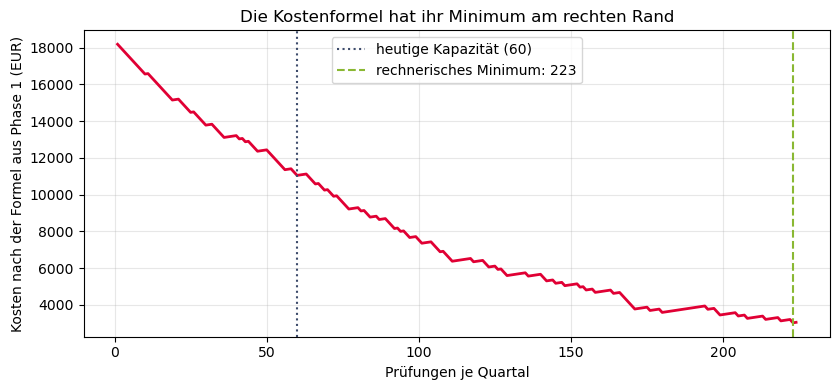

  Kapazität   20:  18 Treffer.   15.170 EUR
  Kapazität   60:  43 Treffer.   11.045 EUR
  Kapazität  120:  73 Treffer.    6.395 EUR
  Kapazität  224: 102 Treffer.    3.050 EUR

Rechnerisches Minimum bei 223 von 224 Rädern.


In [16]:
# Nicht nur 20 bis 120, sondern JEDE Listenlaenge. Wer nur einen Ausschnitt
# rechnet, findet das Minimum am Rand des Ausschnitts und haelt es fuer ein
# Optimum. Genau das ist in einer frueheren Fassung passiert: Dort stand
# "die guenstigste Kapazitaet ist 120" - es war schlicht der groesste
# gepruefte Wert.
alle_k = range(1, len(y_test) + 1)
kosten_k = [liste_bewerten("x", ausgelieferter_score, y_test, kapazitaet=k)["Kosten (EUR)"]
            for k in alle_k]
guenstigste = int(np.argmin(kosten_k)) + 1

plt.figure(figsize=(8.5, 4))
plt.plot(list(alle_k), kosten_k, color="#e00034", lw=2)
plt.axvline(KAPAZITAET, color="#3d4b6b", ls=":", label=f"heutige Kapazität ({KAPAZITAET})")
plt.axvline(guenstigste, color="#8AB833", ls="--",
            label=f"rechnerisches Minimum: {guenstigste}")
plt.xlabel("Prüfungen je Quartal"); plt.ylabel("Kosten nach der Formel aus Phase 1 (EUR)")
plt.title("Die Kostenformel hat ihr Minimum am rechten Rand"); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

for k in [20, 60, 120, len(y_test)]:
    e = liste_bewerten(f"k={k}", ausgelieferter_score, y_test, kapazitaet=k)
    print(f"  Kapazität {k:>4d}: {e['Treffer']:>3d} Treffer, "
          f"{e['Kosten (EUR)']:>8,.0f} EUR".replace(",", "."))
print(f"\nRechnerisches Minimum bei {guenstigste} von {len(y_test)} Rädern.")

**Die Formel empfiehlt, praktisch die ganze Flotte zu prüfen.** Das ist offensichtlich
Unsinn — und der Fehler steckt nicht in der Rechnung, sondern in der Formel:

```text
Kosten = falsch_positive × 25 € + falsch_negative × 180 €
```

Bei fester Listenlänge `k` und `P` positiven Rädern gilt `FP = k − TP` und `FN = P − TP`,
also:

```text
Kosten = 25k + 180P − 205 × TP
```

Jeder zusätzliche Listenplatz kostet 25 € und bringt im Erwartungswert mehr als 25 € an
vermiedenen Ausfällen, solange die Trefferquote über 12 Prozent liegt. Bei einer
Grundrate von 45 Prozent ist das bis zum letzten Rad der Fall.

> **Was in der Formel fehlt:** die Prüfkosten der Treffer. Ein gefundener Schaden
> verursacht Arbeitszeit und Ersatzteile; in dieser Rechnung ist er kostenlos. Ebenso
> fehlt, mit welcher Wahrscheinlichkeit eine Prüfung den Schaden überhaupt findet und
> verhindert.

**Deshalb bleibt die Kapazität hier eine harte Vorgabe und wird nicht optimiert.** Die
Formel taugt, um zwei Verfahren bei *gleicher* Listenlänge zu vergleichen — dafür ist sie
in diesem Notebook auch benutzt worden. Sie taugt nicht, um die Listenlänge selbst zu
wählen.

> **Auch beim Verfahrensvergleich bleibt sie ein Szenario.** Sie unterstellt, dass jeder
> Treffer den Schaden vollständig verhindert, dass jeder verpasste Ausfall genau 180 €
> kostet und dass ein leichter Defekt so teuer ist wie ein fahruntauglicher. Von den
> auffälligen Rädern des Testquartals ist nur ein Drittel fahruntauglich — zwei Listen
> mit gleich vielen Treffern können wirtschaftlich sehr verschieden sein. Wo im Folgenden
> Euro stehen, stehen **Szenariokosten**.

**Und das ist der Punkt, an dem eine Analyse ehrlich sein muss.** Die Frage „sollen wir
eine halbe Stelle in der Werkstatt aufbauen?“ lässt sich mit dieser Kostenformel **gerade
nicht** beantworten. Dafür fehlen die Prüf- und Reparaturkosten der Treffer und die
empirische Wahrscheinlichkeit, dass eine Prüfung einen Schaden überhaupt erkennt und
verhindert.

Eine Analyse, die hier eine Zahl nennt, nennt eine erfundene. Der richtige nächste
Schritt ist kein weiteres Modell, sondern ein Gespräch mit Werkstatt und Controlling
über die tatsächlichen Kosten je Prüfung, Reparatur und Ausfall.

---

1. Business · 2. Data · 3. Data · 4. Modeling · 5. Evaluation · **6. Deployment**

# Phase 6 von 6 — Deployment

> **Leitfrage:** Wie kommt das Modell in den Betrieb — und was passiert danach?
>
> **In diesem Notebook heißt das:** Aus der Auswertung wird eine Liste, die zu Quartalsbeginn in der Werkstatt liegt.

In [17]:
import joblib, datetime

liste = test_zeilen.copy()
liste["rangwert"] = ausgelieferter_score          # KEIN zweiter Wert, kein Umweg
# Wie weit ist der Modellscore von einer Wahrscheinlichkeit entfernt?
# Gemessen, nicht behauptet - und getrennt von der Liste ausgegeben.
print(f"Modellscore im Mittel {p_wald.mean():.1%}, "
      f"tatsächliche Grundrate {float(y_test.mean()):.1%} - "
      f"Abstand {abs(p_wald.mean() - float(y_test.mean())) * 100:.1f} Prozentpunkte.")
print("Als Rangfolge brauchbar, als Wahrscheinlichkeit nicht. Deshalb steht")
print("der Score im Analysebericht, nicht in der Werkstattliste.\n")
liste = liste.sort_values("rangwert", ascending=False).head(KAPAZITAET)
liste["rang"] = range(1, len(liste) + 1)

# ─── SELBSTPRÜFUNG ──────────────────────────────────────────────────
# Die exportierte Liste MUSS die Top 60 des Verfahrens sein, das oben
# als ausgeliefert benannt wurde. In einer früheren Fassung stimmte das
# nicht: Der Text erklärte den Wald zum Sieger, sortiert wurde nach der
# Regel. Die beiden Listen überschnitten sich in 43 von 60 Rädern -
# niemandem fiel es auf. Diese Zeile lässt das Notebook durchfallen.
soll = set(test_zeilen.iloc[np.argsort(-np.asarray(ausgelieferter_score))[:KAPAZITAET]].fahrrad_id)
assert set(liste.fahrrad_id) == soll, (
    f"Die exportierte Liste passt nicht zu '{ausgeliefertes_verfahren}'")
print(f"Selbstprüfung bestanden: Liste = Top {KAPAZITAET} von '{ausgeliefertes_verfahren}'\n")

# Der Modellscore steht NICHT in der ausgelieferten Liste. Er stammt aus
# einem Verfahren, das ausdruecklich nicht freigegeben ist; neben einem
# Rang, den die Regel bestimmt, erzeugt er in der Werkstatt ein zweites,
# widersprechendes Signal. Er gehoert in den Analysebericht, nicht auf
# den Werkstatttisch.
ausgabe = liste[["rang", "rahmennummer", "typ_code", "rangwert", "km_180",
                 "meldungen_bisher", "tage_seit_reparatur"]].copy()
ausgabe["rangwert"] = ausgabe.rangwert.round(0)
ausgabe["km_180"] = ausgabe.km_180.round(0)
ausgabe = ausgabe.rename(columns={
    "rahmennummer": "Rahmennummer", "typ_code": "Typ",
    "rangwert": "km seit letzter Reparatur", "km_180": "km (180 Tage)",
    "meldungen_bisher": "Meldungen bisher", "tage_seit_reparatur": "Tage seit Reparatur"})

print(f"WARTUNGSLISTE  Quartal ab {letzter.date()}   ({KAPAZITAET} Räder)\n")
print(ausgabe.head(15).to_string(index=False))
print(f"\n... und {len(ausgabe) - 15} weitere.")

ausgabe.to_csv("wartungsliste.csv", index=False)

# Das Paket beschreibt, WAS ausgeliefert wird - abgeleitet, nicht getippt.
# Das Modell wandert mit hinein, obwohl es nicht ausgeliefert wird: als
# Beleg, dass es geprueft wurde, und als Ausgangspunkt der naechsten Runde.
paket = {
    "ausgeliefert": ausgeliefertes_verfahren,
    "regel": "Räder nach Kilometern seit der letzten ERLEDIGTEN Reparatur, absteigend",
    "regel_spalte": "km_seit_reparatur",
    "trefferquote_test": round(float(urteile[ausgeliefertes_verfahren][0]["Trefferquote"]), 3),
    "vertrauensintervall_test": [round(float(g), 3)
                                 for g in wilson(urteile[ausgeliefertes_verfahren][0]["Treffer"],
                                                 KAPAZITAET)],
    "geprueft_aber_nicht_ausgeliefert": "Random Forest",
    "modell": wald,
    "merkmalsspalten": list(X_alle.columns),
    "vorteil_modell_validierung_eur": float(vorteil_roll),
    "horizont_tage": HORIZONT_TAGE, "rueckblick_tage": RUECKBLICK_TAGE,
    "kapazitaet": KAPAZITAET,
    "datenherkunft": "ERFUNDENE LEHRDATEN - keine Grundlage für Betriebsentscheidungen",
    "erstellt_am": datetime.date.today().isoformat(),
}
joblib.dump(paket, "wartungsmodell.joblib")
print()
print(f"ausgeliefert: {paket['ausgeliefert']}")
print("geschrieben: wartungsliste.csv, wartungsmodell.joblib")

Modellscore im Mittel 56.9%, tatsächliche Grundrate 45.5% - Abstand 11.4 Prozentpunkte.
Als Rangfolge brauchbar, als Wahrscheinlichkeit nicht. Deshalb steht
der Score im Analysebericht, nicht in der Werkstattliste.

Selbstprüfung bestanden: Liste = Top 60 von 'Faustregel: km seit Reparatur'

WARTUNGSLISTE  Quartal ab 2026-05-26   (60 Räder)

 rang Rahmennummer   Typ  km seit letzter Reparatur  km (180 Tage)  Meldungen bisher  Tage seit Reparatur
    1     WUE-0234  CITY                      592.0           76.0               1.0                710.0
    2     WUE-0187  CITY                      443.0           92.0               1.0                414.0
    3     WUE-0125 EBIKE                      440.0          114.0               1.0                521.0
    4     WUE-0123  CITY                      436.0           77.0               1.0                564.0
    5     WUE-0064  CITY                      428.0           73.0               1.0                596.0
    6     WUE-0059  

### 6.1 Ausgeliefert wird die Regel — und das Modell bleibt im Paket

Bei Gleichstand gewinnt die einfachere Lösung. Das ist keine Bescheidenheit, sondern eine
Rechnung über die Lebensdauer:

| | Faustregel | Random Forest |
|---|---|---|
| Trefferquote auf dem Test | gleich | gleich |
| über die Validierungsquartale | leicht vorn | leicht hinten |
| erklärbar | „das Rad ist seit 592 km nicht in der Werkstatt gewesen" | nur über Umwege |
| Wartungsaufwand | geringer — die Regel selbst ändert sich nicht | vierteljährlich nachtrainieren |
| Abhängigkeiten im Betrieb | Fahrten-, Distanz-, Typ- und Wartungsdaten | dieselben, **zusätzlich** scikit-learn, joblib, Versionsstände |

Die unteren drei Zeilen sind der Preis eines Modells. Er wäre zu zahlen, wenn die oberen
beiden dafür sprächen. Sie tun es nicht.

> ### ⚠ „Eine Zeile SQL" wäre zu schön
>
> Der Sortierausdruck ist eine Zeile. Das Merkmal darunter ist es nicht. `km_seit_reparatur`
> setzt voraus:
>
> 1. Langfahrten über acht Stunden ausschließen,
> 2. gemessene Distanzen verwenden und nur die fehlenden schätzen,
> 3. die Schätzung braucht **je Radtyp** eine Geschwindigkeit — ein unbekannter Typ
>    erzeugt `NaN` und damit ein Rad ganz unten in der Liste,
> 4. die Verknüpfung mit **erledigten** Wartungsaufträgen,
> 5. den Ausschluss offener Schäden,
> 6. eine Stichtagslogik und eine Regel für neue Räder.
>
> **Ausgeliefert wird also nicht eine Regel, sondern eine Regel plus ihre
> Merkmalslogik** — und die gehört genauso versioniert und getestet wie ein Modell. Was
> gegenüber dem Wald entfällt, ist das Nachtrainieren, nicht die Sorgfalt.

> **Ein Modell muss seinen Unterhalt verdienen.** Hier verdient es ihn nicht — und der
> Projektbericht muss das so schreiben, statt das Modell auszuliefern, weil man es nun
> einmal gebaut hat.

**Das Modell bleibt trotzdem im Paket**, aus zwei Gründen: Es belegt, dass die Regel
geprüft wurde und nicht aus Bequemlichkeit gewählt ist. Und es ist der Ausgangspunkt der
nächsten Runde — wenn neue Merkmale dazukommen, wird der Vergleich wiederholt.

> **Der eigentliche Ertrag des Modells steht nicht in der Trefferquote.** Er steht in
> dem, was der Vergleich ausschließt: Auf dieser Merkmalsmenge und über diese fünf
> Perioden ist **kein stabiler Zusatznutzen nachweisbar**. Das ist eine belastbare
> Aussage darüber, wo als Nächstes zu investieren wäre — **nicht in Rechenleistung,
> sondern in Merkmale**, die es heute nicht gibt.

### 6.2 Die Liste ist das eigentliche Produkt

Nicht das Modell, nicht die Confusion-Matrix — **diese Tabelle**. Sie ist so gebaut, dass
die Werkstatt sie ohne Nacharbeit übernehmen kann: Rahmennummer statt Datenbank-ID, und
daneben die Zahlen, die die Reihenfolge begründen. Ein Meister, der ein Rad für
unbedenklich hält, sieht sofort, worauf sich die Liste stützt, und kann widersprechen.

> **In der Liste steht kein Modellscore.** Der Wald wurde mit starken Klassengewichten
> trainiert; seine Ausgabewerte sind eine brauchbare **Rangfolge**, aber keine
> Wahrscheinlichkeiten — der Abstand zwischen mittlerem Score und tatsächlicher
> Grundrate steht oben gerechnet.
>
> Wichtiger noch: Er stammt aus einem Verfahren, das **ausdrücklich nicht freigegeben
> ist**. Neben einem Rang, den die Regel bestimmt, erzeugt eine zweite Zahl in der
> Werkstatt nur ein widersprechendes Signal. Wer beide sehen will, findet sie im
> Analysebericht.

In der VeloCity-Warenwirtschaft (`wawi.butscher.cloud`) gehört diese Liste in den Bereich
**Instandhaltung**, als eigene Ansicht neben den gemeldeten Schäden.

### 6.3 Überwachung — für die Regel, nicht für das Modell

Eine Regel kann man nicht nachtrainieren. Was bei ihr überwacht wird, sind die **Daten,
aus denen ihr Merkmal entsteht** — und die Frage, ob die Liste im Betrieb noch trifft.

| Wache | Schwelle | Reaktion |
|---|---|---|
| Fahrten ohne gemessene Distanz | Anteil steigt deutlich über 40 % | Die Schätzung trägt mehr als geplant — Sensorlage prüfen |
| Unbekannter Radtyp | taucht auf | **Sofort:** Die Geschwindigkeitstabelle kennt ihn nicht, die Kilometer werden zu `NaN` |
| Ausgeschlossene Langfahrten | Zahl steigt | Rückgabeprozess oder Datenerfassung hat sich geändert |
| Wartungsaufträge ohne `erledigt_am` | Anteil steigt | Der Reset des Merkmals greift nicht mehr |
| Räder mit offenem Schaden | Zahl steigt stark | Die Werkstatt kommt nicht nach — die Vorsorgeliste ist dann das falsche Werkzeug |
| Treffsicherheit der Quartalsliste | fällt unter die Grundrate | Die Regel sortiert nicht mehr besser als der Zufall — Daten, Ziel und Regel neu prüfen |
| Räder, die trotz Prüfung ausfallen | steigt | Die Prüfung selbst greift zu kurz — kein Datenproblem |

**Die letzte Zeile ist die wichtigste und wird fast immer vergessen.** Eine perfekte
Rangfolge nützt nichts, wenn die Prüfung den Defekt nicht findet. Dann ist nicht die
Vorhersage falsch, sondern die Maßnahme.

**Und die zweite Zeile ist die unangenehmste:** Sie zeigt, dass die „einfache Regel" gar
nicht so einfach ist — dazu gleich mehr.

Der Random Forest bleibt im Paket, wird aber **nicht** überwacht. Er läuft nicht; für ihn
gilt nur, dass der Vergleich zu wiederholen ist, wenn neue Merkmale dazukommen.

### 6.4 Die Rückkopplung, die dieses Verfahren besonders schwierig macht

Hier steckt eine Falle, die es in Notebook 1 nicht gab:

> **Sobald die Liste benutzt wird, verändert sie die Daten, aus denen sie lernt.**

Ein Rad, das vorsorglich geprüft und instandgesetzt wurde, meldet sich anschließend
*nicht*. Im nächsten Trainingslauf erscheint es damit als „unauffällig“ — obwohl es
gerade deshalb unauffällig war, weil das Modell es erkannt hatte. Das Modell lernt
gegen sich selbst.

**Ein Merkmal `wurde_vorsorglich_geprueft` löst das nicht.** Es sagt, dass geprüft wurde
— nicht, was ohne Prüfung passiert wäre. Genau das ist die Frage, und sie ist an keinem
einzelnen Rad zu beantworten: Man sieht immer nur einen der beiden Ausgänge.

Was tatsächlich hilft, ist ein **Vergleich zwischen Rädern**:

1. **Alles protokollieren:** Auswahlgrund, Prüfdatum, Befund, durchgeführte Reparatur und
   die späteren Meldungen. Ohne dieses Protokoll ist gar nichts auswertbar.
2. **Erst im Schatten mitlaufen lassen:** Liste erzeugen, aber nicht danach handeln. So
   bleibt die Grundrate unverändert und man sieht, ob die Liste trifft.
3. **Dann eine Kontrollgruppe:** Ein fachlich vertretbarer Teil der Flotte wird weiter
   nach dem Standardprozess gewartet. Nur der Unterschied zwischen beiden Gruppen misst,
   was die Maßnahme bewirkt.

Punkt 3 kostet Geld und ist trotzdem richtig: Ohne ihn lässt sich nie sagen, ob die
gesunkene Ausfallquote von der Liste kommt oder vom milden Winter.

> **Und eine Warnung für die Überwachung:** Wenn die Liste wirkt, sinkt die Trefferquote
> — die verhinderten Schäden tauchen als „unauffällig" auf. Eine fallende Trefferquote
> kann also Erfolg oder Versagen bedeuten. Ohne Kontrollgruppe ist sie nicht deutbar.

---

# Der Kreislauf schließt sich

| Phase | Ergebnis |
|---|---|
| 1 Business Understanding | Aus „vorausschauend warten“ wurde eine Kostenmatrix: 180 € je verpasstem Ausfall gegen 25 € je unnötiger Prüfung — Verhältnis rund 7 : 1. Zwei Erfolgskriterien, eines davon der Vergleich mit der heutigen Faustregel |
| 2 Data Understanding | Nutzung und Meldungen hängen zusammen (r ≈ 0,7), aber nicht deterministisch. Der Anteil auffälliger Räder schwankt saisonal um mehr als das Fünffache |
| 3 Data Preparation | Zeitlicher Schnitt statt Gesamtbetrachtung. Gemessene Distanzen bevorzugt, Langfahrten ausgeschlossen, Räder mit offenem Schaden aus der Prognosepopulation genommen. Rückgesetzt wird bei der **erledigten Reparatur**, nicht bei der Meldung |
| 4 Modeling | Drei Faustregeln als Maßstab, dann Baum und Wald — beide mit `class_weight` aus der Kostenmatrix |
| 5 Evaluation | Auf dem Testquartal Gleichstand. Über fünf Validierungsquartale liegt die Faustregel vorn. Das Wilson-Intervall zeigt, dass 60 Beobachtungen die beiden Verfahren gar nicht trennen können |
| 6 Deployment | **Ausgeliefert wird die Faustregel.** Das Modell bleibt im Paket als Beleg der Prüfung und als Ausgangspunkt der nächsten Runde |

**Drei Sätze, die aus diesem Notebook bleiben sollten**

> Ein Modell kann gegen eine Baseline gewinnen, weil die Baseline schlecht gebaut ist.
> Wer den Vergleich ernst meint, gibt der Regel dieselbe Sorgfalt wie dem Modell.

> Ein einzelnes gutes Quartal ist kein Ergebnis. Bei einer Grundrate, die zwischen 8 und
> 46 Prozent schwankt, entscheidet die Jahreszeit mit — nicht nur das Verfahren.

> Treffsicherheit und Abdeckung sind zwei Zahlen. Sieben von zehn geprüften Rädern
> melden sich; vier von zehn auffälligen Rädern werden erreicht. Beide sind richtig.

**Was offen bleibt — ausdrücklich**

1. **Erfundene Daten.** Alle Euro-Beträge sind Szenariorechnungen, keine gemessenen
   Ersparnisse. Vor einem echten Einsatz müsste alles mit realen Daten neu validiert
   werden.
2. **Das Ziel ist zu weit gefasst.** Vorhergesagt wird *irgendeine* Meldung. Von den 102
   auffälligen Rädern des Testquartals hat nur ein Drittel eine Meldung der Stufe
   „fahruntauglich". Leichte und schwere Schäden kosten in unserer Matrix dasselbe.
3. **Die Wirksamkeit der Prüfung ist unbekannt.** Wir wissen nicht, welchen Anteil der
   Schäden eine Inspektion überhaupt findet und verhindert. Ohne diese Größe ist jede
   Nutzenrechnung eine Obergrenze.
4. **Die Kostenformel trägt keine Kapazitätsentscheidung.** Ihr Minimum liegt bei der
   ganzen Flotte, weil die Prüfkosten der Treffer fehlen (Abschnitt 5.7).
5. **Die Rückkopplung ist nicht gelöst.** Dafür bräuchte es Protokoll, Schattenbetrieb
   und Kontrollgruppe (Abschnitt 6.4).
6. **Kein echter Schattenbetrieb.** Der Teststichtag liegt in der Vergangenheit, sein
   Ausgang war beim Rechnen bekannt.
7. **Fünf Validierungsquartale sind wenig.** Für eine saisonale Aussage bräuchte es
   mehrere Jahre.
8. **Der Rückblick von 180 Tagen ist gesetzt, nicht geprüft.** Vielleicht sagen 60 Tage
   mehr über den nächsten Defekt aus als ein halbes Jahr.
9. **Was ein Rad *erlebt* hat, fehlt** — Stürze, Vandalismus, Standzeiten im Regen. Auch
   die Stationen, an denen es unterwegs war, sind kein Merkmal.

**Weiter geht es mit Notebook 3 — Clustering und Segmentierung:** Dort gibt es zum ersten
Mal **kein Label**. Niemand sagt dem Verfahren, was richtig ist; es soll die Gruppen
selbst finden.